In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
path = '/kaggle/input/competitions/titanic/train.csv'
df = pd.read_csv(path)
stats_summary = df.describe()
print("Bảng tóm tắt thống kê:\n", stats_summary)

age_mean = df['Age'].mean()
age_median = df['Age'].median()
age_mode = df['Age'].mode()[0]
age_var = df['Age'].var()
age_std = df['Age'].std()
age_skew = df['Age'].skew()
age_kurt = df['Age'].kurtosis()

Bảng tóm tắt thống kê:
        PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [7]:
print("\n--- Thống kê chi tiết biến 'Age' ---")
print(f"Mean: {age_mean:.2f}, Median: {age_median:.2f}, Mode: {age_mode:.2f}")
print(f"Variance: {age_var:.2f}, Standard Deviation: {age_std:.2f}")
print(f"Skewness: {age_skew:.2f}, Kurtosis: {age_kurt:.2f}")


--- Thống kê chi tiết biến 'Age' ---
Mean: 29.70, Median: 28.00, Mode: 24.00
Variance: 211.02, Standard Deviation: 14.53
Skewness: 0.39, Kurtosis: 0.18


In [8]:
import pandas as pd
from IPython.display import display

# Giả sử DataFrame 'df' đã được khởi tạo từ tập dữ liệu Kaggle
# Tự động chọn các cột chứa dữ liệu dạng số (int, float)
numeric_cols = df.select_dtypes(include=['number']).columns

def descriptive_stats_with_outlier(s: pd.Series) -> pd.Series:
    s = s.dropna()
    q1 = s.quantile(0.25)
    q2 = s.quantile(0.50)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    # Tạo mask boolean để lọc các giá trị outlier
    outlier_mask = (s < lower) | (s > upper)

    return pd.Series({
        'count': s.count(),
        'min': s.min(),
        'q1 (25%)': q1,
        'median (50%)': q2,
        'q3 (75%)': q3,
        'max': s.max(),
        'IQR': iqr,
        'lower_fence': lower,
        'upper_fence': upper,
        'outlier_count': outlier_mask.sum(),
        'outlier_ratio': outlier_mask.mean(),
        'variance': s.var(ddof=1), # Bậc tự do (Degrees of Freedom) = 1 cho dữ liệu mẫu
        'std_dev': s.std(ddof=1),
    })

# Áp dụng hàm cho toàn bộ các cột số và transpose (T) để dễ quan sát
stats_table = pd.DataFrame({
    col: descriptive_stats_with_outlier(df[col]) for col in numeric_cols
}).T

print('Bảng thống kê đầy đủ (bao gồm Five-number summary, Quartiles, IQR, Outlier, Variance, Std):')
display(stats_table)

Bảng thống kê đầy đủ (bao gồm Five-number summary, Quartiles, IQR, Outlier, Variance, Std):


,count,min,q1 (25%),median (50%),q3 (75%),max,IQR,lower_fence,upper_fence,outlier_count,outlier_ratio,variance,std_dev
PassengerId,891.0,1.00,223.5000,446.0000,668.5,891.0000,445.0000,-444.0000,1336.0000,0.0,0.000000,66231.000000,257.353842
Survived,891.0,0.00,0.0000,0.0000,1.0,1.0000,1.0000,-1.5000,2.5000,0.0,0.000000,0.236772,0.486592
Pclass,891.0,1.00,2.0000,3.0000,3.0,3.0000,1.0000,0.5000,4.5000,0.0,0.000000,0.699015,0.836071
Age,714.0,0.42,20.1250,28.0000,38.0,80.0000,17.8750,-6.6875,64.8125,11.0,0.015406,211.019125,14.526497
SibSp,891.0,0.00,0.0000,0.0000,1.0,8.0000,1.0000,-1.5000,2.5000,46.0,0.051627,1.216043,1.102743
Parch,891.0,0.00,0.0000,0.0000,0.0,6.0000,0.0000,0.0000,0.0000,213.0,0.239057,0.649728,0.806057
Fare,891.0,0.00,7.9104,14.4542,31.0,512.3292,23.0896,-26.7240,65.6344,116.0,0.130191,2469.436846,49.693429


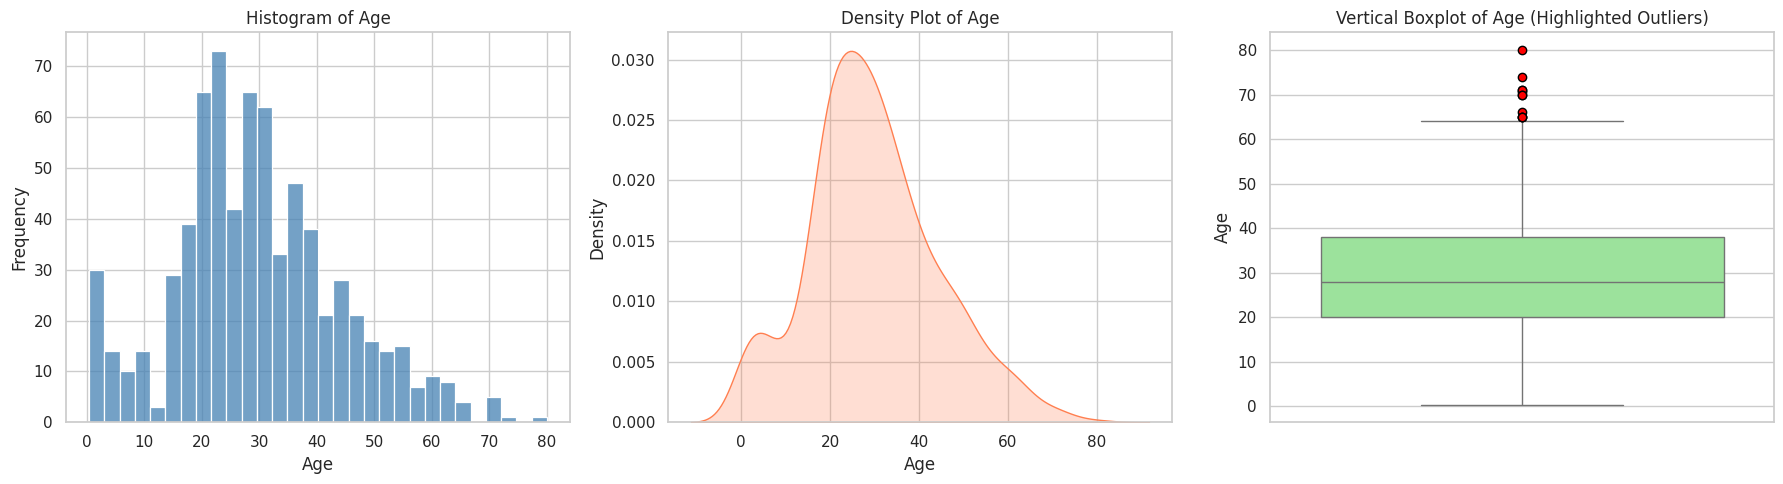

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram
sns.histplot(df['Age'].dropna(), bins=30, kde=False, ax=axes[0], color='steelblue')
axes[0].set_title('Histogram of Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# 2. Density Plot 
sns.kdeplot(df['Age'].dropna(), fill=True, ax=axes[1], color='coral')
axes[1].set_title('Density Plot of Age')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')

# 3. Boxplot
flier_properties = dict(marker='o', markerfacecolor='red', markersize=6, linestyle='none', markeredgecolor='black')
sns.boxplot(y=df['Age'].dropna(), ax=axes[2], color='lightgreen', flierprops=flier_properties)
axes[2].set_title('Vertical Boxplot of Age (Highlighted Outliers)')
axes[2].set_ylabel('Age')
plt.tight_layout()
plt.show()

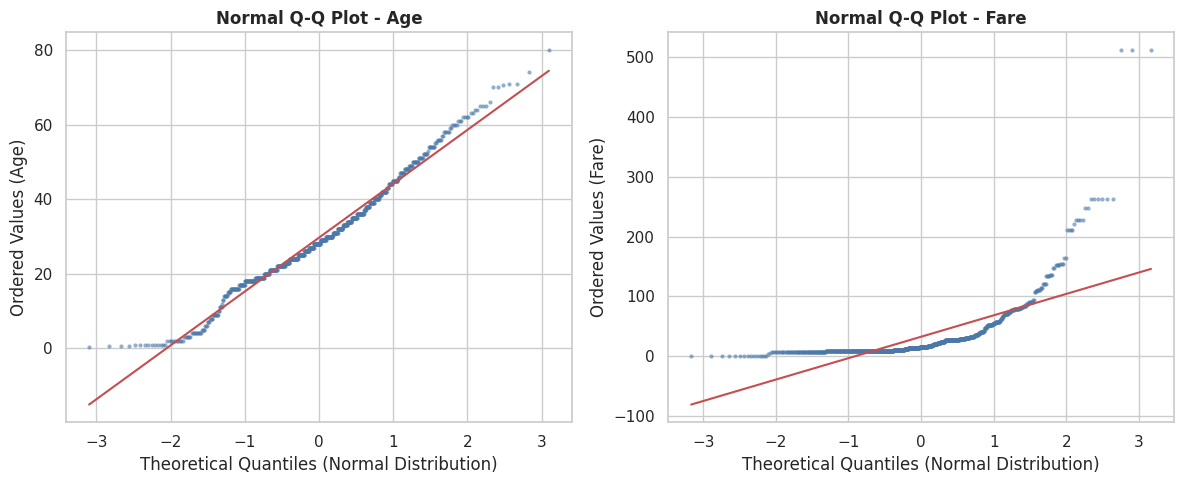

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# Thiết lập style học thuật
sns.set_theme(style="whitegrid")

# Tải dữ liệu
url = "/kaggle/input/competitions/titanic/train.csv"
df = pd.read_csv(url)

# Chọn các biến liên tục (Age, Fare) để kiểm định 
continuous_cols = ['Age', 'Fare']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes, continuous_cols):
    data_clean = df[col].dropna()
    stats.probplot(data_clean, dist='norm', plot=ax)
    
    ax.get_lines()[0].set_marker('.')
    ax.get_lines()[0].set_markerfacecolor('#4C78A8')
    ax.get_lines()[0].set_markeredgecolor('none')
    ax.get_lines()[0].set_alpha(0.6)
    
    ax.set_title(f'Normal Q-Q Plot - {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles (Normal Distribution)')
    ax.set_ylabel(f'Ordered Values ({col})')

plt.tight_layout()
plt.show()

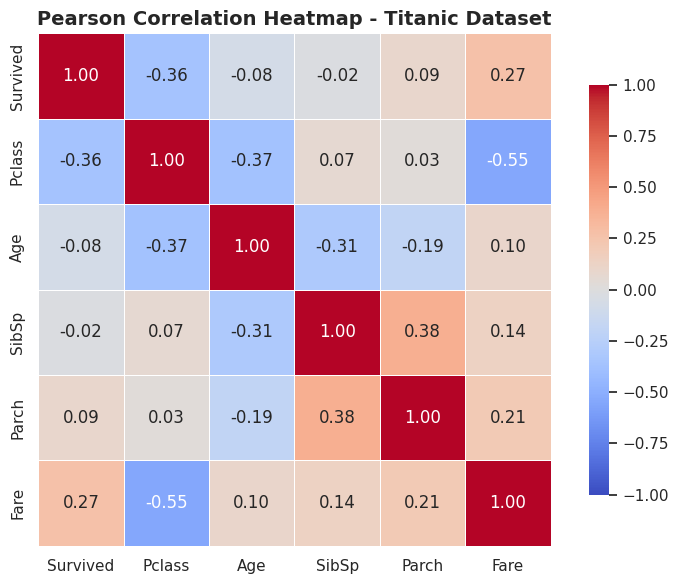

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style
sns.set_theme(style="white")
url = "/kaggle/input/competitions/titanic/train.csv"
df = pd.read_csv(url)

corr_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
df_corr = df[corr_cols].dropna()

# 3. Tính toán ma trận tương quan 
corr_matrix = df_corr.corr(method='pearson')

plt.figure(figsize=(8, 6))
import numpy as np

sns.heatmap(corr_matrix,  
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1, 
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title('Pearson Correlation Heatmap - Titanic Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()